# 02 - Exploratory Data Analysis (EDA)

## Projet : AI BUISNESS ADVISOR V2 

### Objectif 

Cette étape vise à explorer les relations présentes dans les données avant toute opération de nettoyage définitif ou de modélisation 

L'analyse porte sur deux datasets indépendants : 

1. 'freMTPL2freq' 
    - occurence des sinistres 
    - fréquence des sinistres 

2. 'Vehicule Claim Fraud'
    - classification fraude / non-fraude 

Les objectifs sont : 

- comprendre les distributions des variables 
- identifier les variables liées potentiellement aux cible 
- détecter les relations non linéaires 
- identifier les effets de l'exposition dans le dataset assurance 
- étudier le déséquilibre des classes 
- détecter des interactions potentielles 
- identifier les risques de data leakage 
- formuler des hypothèses pour le nettoyage et le feature engineering 


aucune modification permanente des données brutes n'est effectuée 

In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 

from pathlib import Path 

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)
pd.set_option("display.width",200)

In [3]:
cwd = Path.cwd()

possible_paths = [
    cwd / "data" / "raw",
    cwd / "data-science" / "data" / "raw",
    cwd.parent / "data" / "raw"
]

RAW_DIR = None
for path in possible_paths:
    if path.exists():
        RAW_DIR = path
        break
if RAW_DIR is None:
    raise FileNotFoundError(
        "Could not find the raw data directory. "
        "Please ensure that the 'data/raw' directory exists."
    )

print("RAW_DIR:", RAW_DIR.resolve())

RAW_DIR: C:\Users\user\ai-business-advisor-v2\data-science\data\raw


In [4]:
FREQ_PATH = RAW_DIR / "freMTPL2freq.csv"
FRAUD_PATH = RAW_DIR / "fraud_oracle.csv"

df_freq = pd.read_csv(FREQ_PATH)
df_fraud = pd.read_csv(FRAUD_PATH)

print("freMTPL2freq", df_freq.shape)
print("Fraud  :", df_fraud.shape)

freMTPL2freq (678013, 12)
Fraud  : (15420, 33)


In [5]:
freq_eda = df_freq.copy()
fraud_eda = df_fraud.copy()

In [6]:
FIGURES_DIR  = RAW_DIR.parent.parent / "reports" / "figures" / "eda"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(FIGURES_DIR.resolve())

C:\Users\user\ai-business-advisor-v2\data-science\reports\figures\eda


# Partie A - EDA freMTPL2freq

Le dataset décrit des polices d'assurance automobile 

Deux notions différentes doivent etre distinguées :

### Occurence 

La police a-t-elle enregistré au moins un sinistre ?

'has_claim = ClaimNb > 0' 

C'est un futur problème de classification binaire 

### Fréquence

Combien de sinistres sont observés par unité d'exposition ?

Une mesure agrégée appropiée est :

'nombre total de sisnitres / exposition totale'

L'exposition doit etre prise en compte car toutes les polices 
ne sont pas observées pendant la meme durée 

In [7]:
total_policices = len(freq_eda)

total_claims = freq_eda["ClaimNb"].sum()

total_exposure = freq_eda["Exposure"].sum()

mean_claims_per_policy = freq_eda["ClaimNb"].mean()

claim_frequency = total_claims / total_policices

claim_occurence_rate = (freq_eda["ClaimNb"] > 0).mean()

print("Nombre de polices :", total_policices)
print("Nombre total de sinistres :", total_claims)
print("Exposition totale :", total_exposure)
print("Nombre moyen de sinistres par police :", mean_claims_per_policy)
print("Fréquence de sinistres :", claim_frequency)
print("Taux d'occurrence de sinistres :", claim_occurence_rate)

Nombre de polices : 678013
Nombre total de sinistres : 36102
Exposition totale : 358499.44546277856
Nombre moyen de sinistres par police : 0.05324676665491664
Fréquence de sinistres : 0.05324676665491664
Taux d'occurrence de sinistres : 0.05023502499214617


### Interprétation 

La majorité des polices ne déclare pas aucune sisnitre 

Environ 5 % des polices présentent au moins un sisnitre 

Cependant , les contrats ont une durée d'exposition différentes 
La fréquence agrégée doit etre calculée en rapportant le nombre de sinistres à l'exposition totale 

Cette distinction sera particulièrement importante lors de la future modélisation de fréquence, ou l'exposition devra etre intégrée explicitement 

In [8]:
freq_eda["Exposure"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    678013.000000
mean          0.528750
std           0.364442
min           0.002732
1%            0.008219
5%            0.040000
25%           0.180000
50%           0.490000
75%           0.990000
95%           1.000000
99%           1.000000
max           2.010000
Name: Exposure, dtype: float64

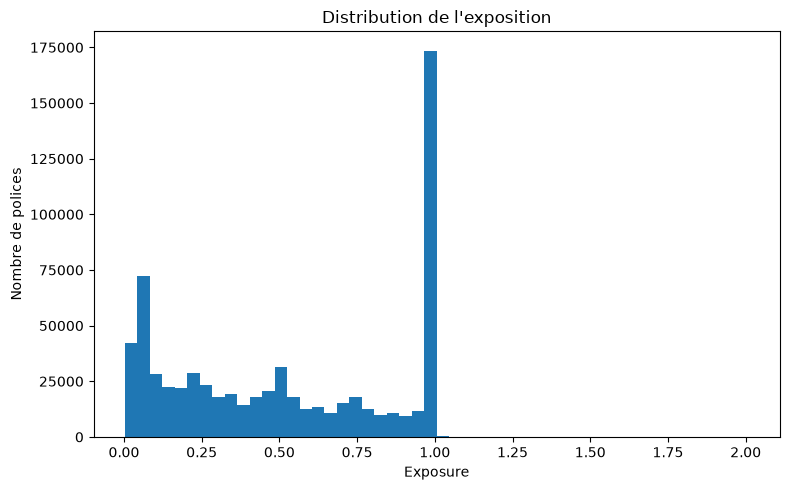

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(
    freq_eda["Exposure"],
    bins=50,
)

plt.title("Distribution de l'exposition")
plt.xlabel("Exposure")
plt.ylabel("Nombre de polices")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "freq_exposure_distribution.png", dpi=150)
plt.show()

In [10]:
freq_eda.loc[
    freq_eda["Exposure"] > 1,
    "Exposure"
].describe()

count    1224.000000
mean        1.113840
std         0.159296
min         1.010000
25%         1.020000
50%         1.040000
75%         1.150000
max         2.010000
Name: Exposure, dtype: float64

In [11]:
freq_eda.loc[
    freq_eda["Exposure"] > 1,
    "Exposure"
].value_counts().head(20)

Exposure
1.01    270
1.03    143
1.02    143
1.04     69
1.06     47
1.07     38
1.08     35
1.15     30
1.09     29
1.05     28
1.11     28
1.12     26
1.13     23
1.16     21
1.10     17
1.20     16
1.18     16
1.17     14
1.14     14
1.19     14
Name: count, dtype: int64

In [12]:
claim_counts = (
    freq_eda["ClaimNb"]
    .value_counts()
    .sort_index()
)

claim_counts

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

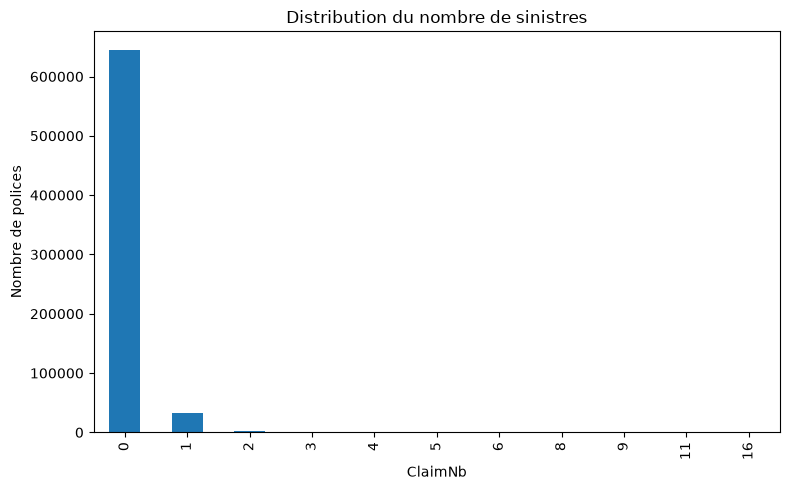

In [13]:
plt.figure(figsize=(8,5))

claim_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution du nombre de sinistres"
)

plt.xlabel(
    "ClaimNb"
)

plt.ylabel(
    "Nombre de polices"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "freq_claimnb_distribution.png",
    dpi=150
)

plt.show()

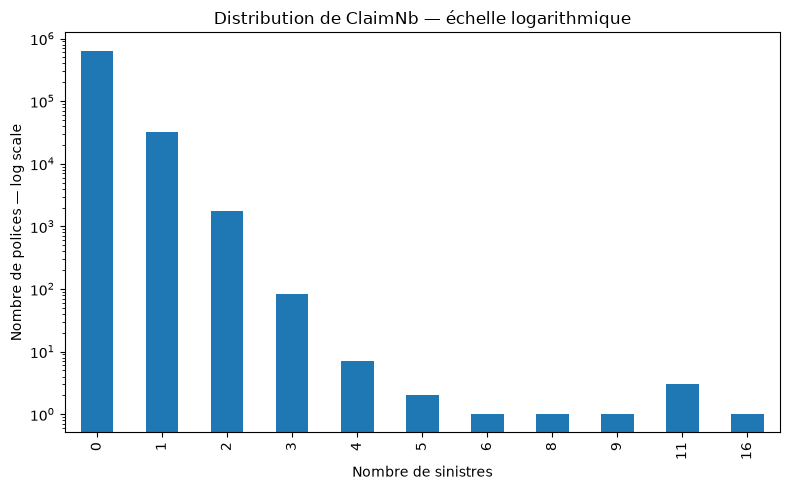

In [14]:
plt.figure(figsize=(8, 5))

claim_counts.plot(
    kind="bar"
)

plt.yscale("log")

plt.title(
    "Distribution de ClaimNb — échelle logarithmique"
)

plt.xlabel(
    "Nombre de sinistres"
)

plt.ylabel(
    "Nombre de polices — log scale"
)

plt.tight_layout()

plt.show()

In [15]:
freq_eda["has_claim"] = (
    freq_eda["ClaimNb"] > 0

).astype(int)

In [16]:
freq_eda["has_claim"].value_counts(
    normalize=True
) * 100

has_claim
0    94.976498
1     5.023502
Name: proportion, dtype: float64

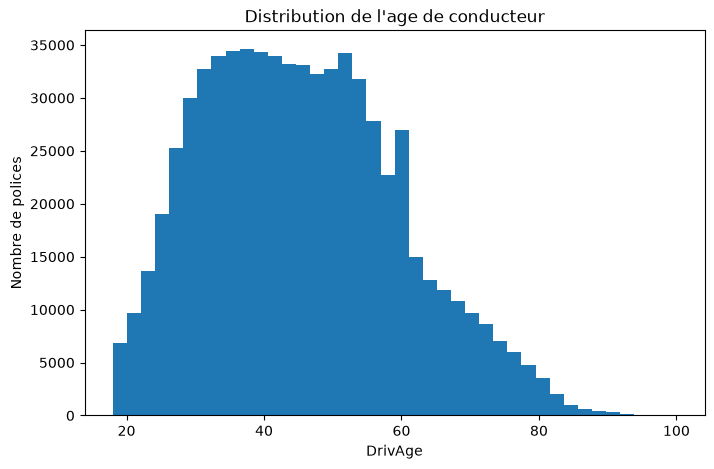

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    freq_eda["DrivAge"],
    bins=40
)

plt.title(
    "Distribution de l'age de conducteur"
)

plt.xlabel(
    "DrivAge"
)

plt.ylabel(
    "Nombre de polices"
)

plt.tight_layout

plt.savefig(
    FIGURES_DIR / "freq_drivage_distribution.png",
    dpi=150
)

plt.show()

In [18]:
freq_eda["DrivAgeBin"] = pd.cut(
    freq_eda["DrivAge"],
    bins=[
        17,
        24,
        34,
        44,
        54,
        64,
        74,
        100
    ],
    labels=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65-74",
        "75-100"

    ],
    include_lowest=True
)

In [19]:
def claim_rate_table(
        df,
        group_col
):

    table = (
        df
        .groupby(
            group_col,
            observed=True
        )
        .agg(
            n=("IDpol","size"),
            exposure=("Exposure","sum"),
            claims=("ClaimNb","sum"),
            occurence_rate=("has_claim","mean")
            
        )
    )

    table["claim_frequency"] = (
        table["claims"]
        / table["exposure"]
    )

    return table 

In [20]:
age_claim_table = claim_rate_table(
    freq_eda,
    "DrivAgeBin"
)

age_claim_table

,n,exposure,claims,occurence_rate,claim_frequency
DrivAgeBin,,,,,
18-24,30198,12489.161085,2364,0.072058,0.189284
25-34,140947,64598.614437,6396,0.042952,0.099011
35-44,170578,87391.452517,8145,0.045299,0.093201
45-54,164034,89852.746482,9513,0.054623,0.105873
55-64,99094,56176.951112,5124,0.048903,0.091212
65-74,50821,32207.190968,2986,0.055607,0.092712
75-100,22341,15783.328863,1574,0.065843,0.099725


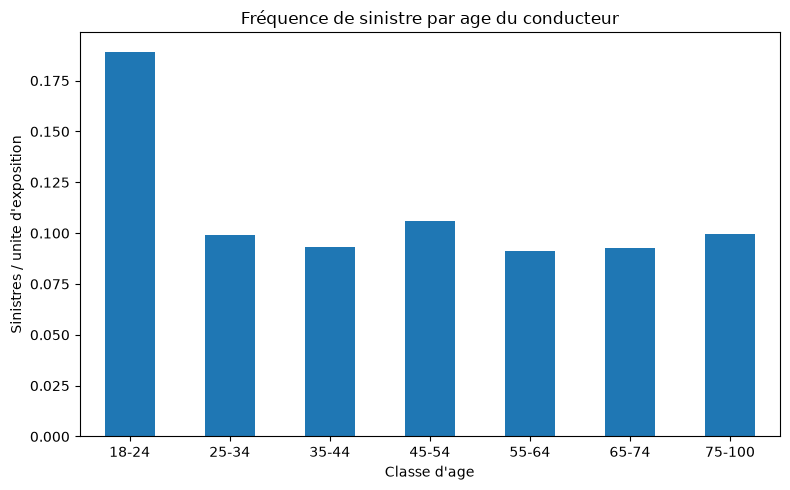

In [21]:
plt.figure(figsize=(8,5))

age_claim_table[
    "claim_frequency"
].plot(
    kind="bar"
)

plt.title("Fréquence de sinistre par age du conducteur")
plt.xlabel("Classe d'age")
plt.ylabel("Sinistres / unite d'exposition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "freq_drivage_claim_frequency.png",dpi=150)
plt.show()

### Hypothèse - age conducteur 

La fréquence des sinistres n'évolue pas linéraiement avec l'age 

Les conducteurs de 18 à 24 présentent une fréquence descriptive nettement supérieure à plusieurs autres groupes 

Cette observation suggère que 'DrivAge' pourrait avoir une relation non linéaire  avec la cible

Ils ne s'agit cependant que d'une association descriptive et non d'une relation causale

In [24]:
freq_eda["VehAgeBin"] = pd.cut(
    freq_eda["VehAge"],
    bins=[
        -1,
        2,
        5,
        10,
        15,
        20,
        100
    ],
    labels=[
        "0-2",
        "3-5",
        "6-10",
        "11-25",
        "16-20",
        "+21"
    ]
)

In [25]:
veh_age_table = claim_rate_table(
    freq_eda,
    "VehAgeBin"
)

veh_age_table

,n,exposure,claims,occurence_rate,claim_frequency
VehAgeBin,,,,,
0-2,188147,79176.055348,10904,0.054484,0.137718
3-5,132490,72040.123776,6743,0.047943,0.093601
6-10,171594,99008.916360,9846,0.054233,0.099446
11-25,134063,77990.975407,6648,0.046829,0.085241
16-20,43397,25136.158607,1685,0.037238,0.067035
+21,8322,5147.215965,276,0.030882,0.053621


In [33]:
print("dtype BonusMalus :", freq_eda["BonusMalus"].dtype)

print("\nTypes Python présents :")
print(
    freq_eda["BonusMalus"]
    .map(type)
    .value_counts()
)

dtype BonusMalus : category

Types Python présents :
BonusMalus
<class 'str'>    678013
Name: count, dtype: int64


In [34]:
mask_string = (
    freq_eda["BonusMalus"]
    .map(lambda x: isinstance(x, str))
)

print(
    "Nombre de valeurs de type str :",
    mask_string.sum()
)

freq_eda.loc[
    mask_string,
    ["IDpol", "BonusMalus"]
].head(20)

Nombre de valeurs de type str : 678013


,IDpol,BonusMalus
0,1.0,50
1,3.0,50
2,5.0,50
3,10.0,50
4,11.0,50
5,13.0,50
6,15.0,50
7,17.0,61-80
8,18.0,61-80
9,21.0,50


In [35]:
freq_eda.loc[
    mask_string,
    "BonusMalus"
].value_counts().head(30)

BonusMalus
50         384156
61-80      118755
51-60       94446
81-100      72862
101-150      7585
151-230       209
Name: count, dtype: int64

In [36]:
freq_eda["BonusMalus"] = (
    df_freq["BonusMalus"].copy()
)

In [37]:
print(
    freq_eda["BonusMalus"].dtype
)

print(
    freq_eda["BonusMalus"].head()
)

int64
0    50
1    50
2    50
3    50
4    50
Name: BonusMalus, dtype: int64


In [38]:
freq_eda["BonusMalusBin"] = pd.cut(
    freq_eda["BonusMalus"],
    bins=[
        49,
        50,
        60,
        80,
        100,
        150,
        230
    ],
    labels=[
        "50",
        "51-60",
        "61-80",
        "81-100",
        "101-150",
        "151-230"
    ],
    include_lowest=True
)

In [39]:
bonus_table = claim_rate_table(
    freq_eda,
    "BonusMalusBin"
)

bonus_table

,n,exposure,claims,occurence_rate,claim_frequency
BonusMalusBin,,,,,
50,384156,225233.130903,18056,0.044636,0.080166
51-60,94446,47985.497013,4553,0.045878,0.094883
61-80,118755,53065.346794,7057,0.055821,0.132987
81-100,72862,28644.151750,5094,0.065027,0.177837
101-150,7585,3476.190806,1288,0.154647,0.370521
151-230,209,95.128197,54,0.191388,0.567655


In [40]:
bonus_table["n"]

BonusMalusBin
50         384156
51-60       94446
61-80      118755
81-100      72862
101-150      7585
151-230       209
Name: n, dtype: int64

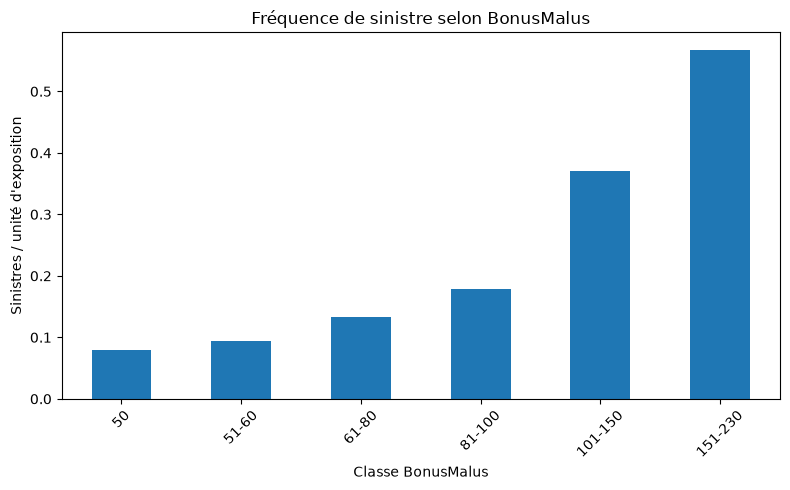

In [42]:
plt.figure(figsize=(8,5))

bonus_table[
    "claim_frequency"
].plot(
    kind="bar"
)

plt.title(
    "Fréquence de sinistre selon BonusMalus"
)

plt.xlabel(
    "Classe BonusMalus"
)

plt.ylabel("Sinistres / unité d'exposition")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "freq_bonusmalus_claim_frequency.png",
    dpi=150
)

plt.show()

In [43]:
freq_eda["Density"].describe(
    percentiles=[
        0.01,
        0.25,
        0.50,
        0.75,
        0.99
    ]
)

count    678013.000000
mean       1792.422405
std        3958.646564
min           1.000000
1%           10.000000
25%          92.000000
50%         393.000000
75%        1658.000000
99%       27000.000000
max       27000.000000
Name: Density, dtype: float64

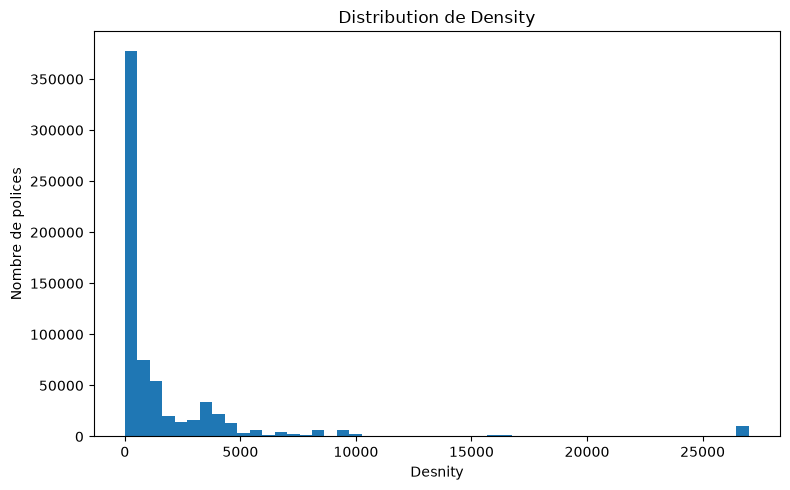

In [44]:
plt.figure(figsize=(8,5))

plt.hist(
    freq_eda["Density"],
    bins=50
)

plt.title(
    "Distribution de Density"
)

plt.xlabel(
    "Desnity"
)

plt.ylabel(
    "Nombre de polices"
)

plt.tight_layout()

plt.show()

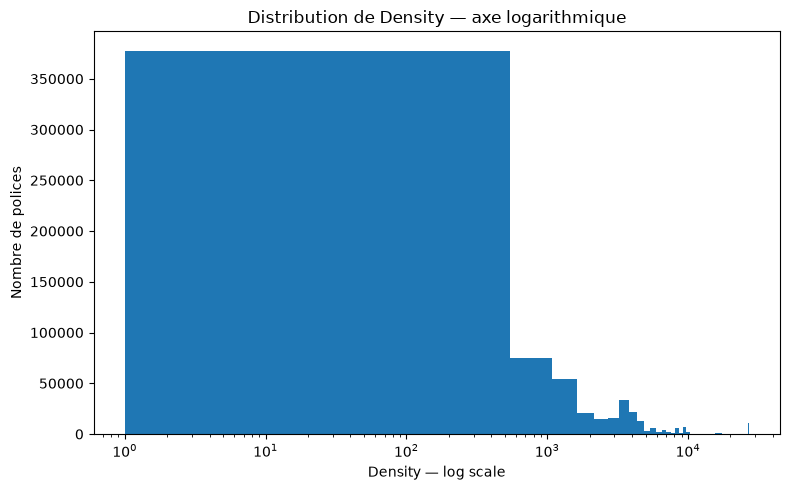

In [45]:
plt.figure(figsize=(8, 5))

plt.hist(
    freq_eda["Density"],
    bins=50
)

plt.xscale("log")

plt.title(
    "Distribution de Density — axe logarithmique"
)

plt.xlabel(
    "Density — log scale"
)

plt.ylabel(
    "Nombre de polices"
)

plt.tight_layout()

plt.show()

In [47]:
freq_eda["DensityQuartile"] = pd.qcut(
    freq_eda["Density"],
    q=4,
    duplicates="drop"
)

density_table = claim_rate_table(
    freq_eda,
    "DensityQuartile"
)

density_table

,n,exposure,claims,occurence_rate,claim_frequency
DensityQuartile,,,,,
"(0.999, 92.0]",169973,99733.989900,8389,0.047090,0.084114
"(92.0, 393.0]",170244,92281.938862,8572,0.047784,0.092889
"(393.0, 1658.0]",168456,87962.080039,9311,0.051818,0.105852
"(1658.0, 27000.0]",169340,78521.436661,9830,0.054281,0.125189


In [48]:
area_table = claim_rate_table(
    freq_eda,
    "Area"
)

area_table.sort_values(
    "claim_frequency"
)

,n,exposure,claims,occurence_rate,claim_frequency
Area,,,,,
A,103957,61969.377712,5063,0.046471,0.081702
B,75459,43012.323931,3800,0.048106,0.088347
C,191880,104449.003785,9875,0.048760,0.094544
D,151596,77120.191692,8428,0.052059,0.109284
E,137167,63819.314270,7805,0.053191,0.122298
F,17954,8129.234074,1131,0.058761,0.139127


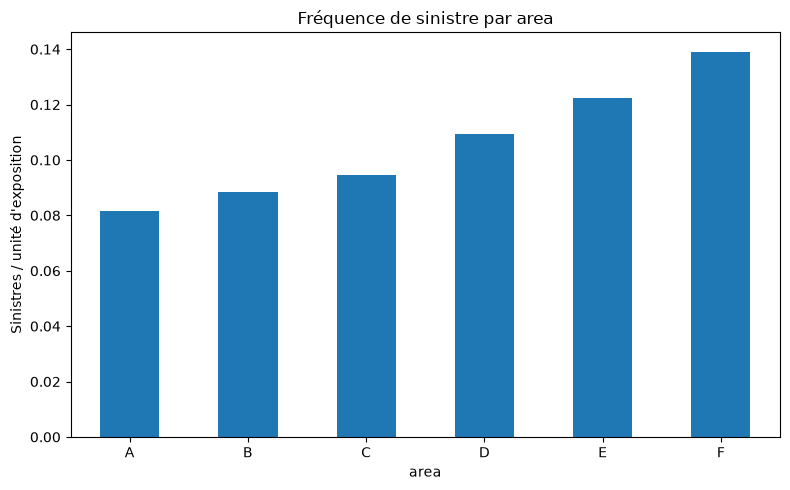

In [49]:
plt.figure(figsize=(8,5))

area_table[
    "claim_frequency"
].sort_index().plot(
    kind="bar"
)

plt.title(
    "Fréquence de sinistre par area"
)

plt.xlabel("area")
plt.ylabel(
    "Sinistres / unité d'exposition"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "freq_area_claim_frequency.png"
)

plt.show()

In [50]:
gas_table = claim_rate_table(
    freq_eda,
    "VehGas"
)

gas_table

,n,exposure,claims,occurence_rate,claim_frequency
VehGas,,,,,
Diesel,332136,170660.893127,16648,0.047297,0.097550
Regular,345877,187838.552336,19454,0.053056,0.103568


In [51]:
region_table = claim_rate_table(
    freq_eda,
    "Region"
)

region_table.sort_values(
    "claim_frequency",
    ascending=False
)

,n,exposure,claims,occurence_rate,claim_frequency
Region,,,,,
R94,4516,1765.935399,247,0.048716,0.139869
R21,3026,1205.831509,160,0.049240,0.132689
R11,69791,30208.641954,3978,0.053202,0.131684
R22,7994,3574.410221,439,0.052664,0.122817
R82,84752,45347.417286,5032,0.056164,0.110966
R42,2200,1209.115823,133,0.056364,0.109998
R93,79315,35790.321015,3907,0.045704,0.109164
R74,4567,2395.994542,259,0.052989,0.108097
R91,35805,14736.104177,1547,0.038793,0.104980


In [52]:
region_table.sort_values(
    "n"
).head()

,n,exposure,claims,occurence_rate,claim_frequency
Region,,,,,
R43,1326,564.012946,57,0.040724,0.101062
R42,2200,1209.115823,133,0.056364,0.109998
R21,3026,1205.831509,160,0.049240,0.132689
R94,4516,1765.935399,247,0.048716,0.139869
R74,4567,2395.994542,259,0.052989,0.108097


In [53]:
brand_table = claim_rate_table(
    freq_eda,
    "VehBrand"
)

brand_table.sort_values(
    "claim_frequency",
    ascending=False
)

,n,exposure,claims,occurence_rate,claim_frequency
VehBrand,,,,,
B12,166024,64808.608718,8859,0.049728,0.136695
B11,13585,6887.817279,721,0.050129,0.104678
B5,34753,19992.062695,2020,0.055103,0.101040
B3,53395,28592.876331,2818,0.050023,0.098556
B13,12178,6772.032216,649,0.050337,0.095835
B4,25179,13775.496080,1312,0.049803,0.095242
B6,28548,15684.953599,1462,0.048620,0.093210
B1,162736,95351.059578,8677,0.050247,0.091001
B10,17707,9496.014123,858,0.046140,0.090354


In [54]:
numeric_cols_freq = [
    "ClaimNb",
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

corr_freq = (
    freq_eda[numeric_cols_freq]
    .corr(method="spearman")
)

corr_freq

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
ClaimNb,1.000000,0.071328,-0.003482,-0.022082,0.011582,0.037970,0.012899
Exposure,0.071328,1.000000,-0.036198,0.184161,0.164207,-0.195501,-0.122867
VehPower,-0.003482,-0.036198,1.000000,-0.002268,0.040393,-0.068385,-0.011934
VehAge,-0.022082,0.184161,-0.002268,1.000000,-0.077986,0.081869,-0.102232
DrivAge,0.011582,0.164207,0.040393,-0.077986,1.000000,-0.571323,-0.044467
BonusMalus,0.037970,-0.195501,-0.068385,0.081869,-0.571323,1.000000,0.139129
Density,0.012899,-0.122867,-0.011934,-0.102232,-0.044467,0.139129,1.000000


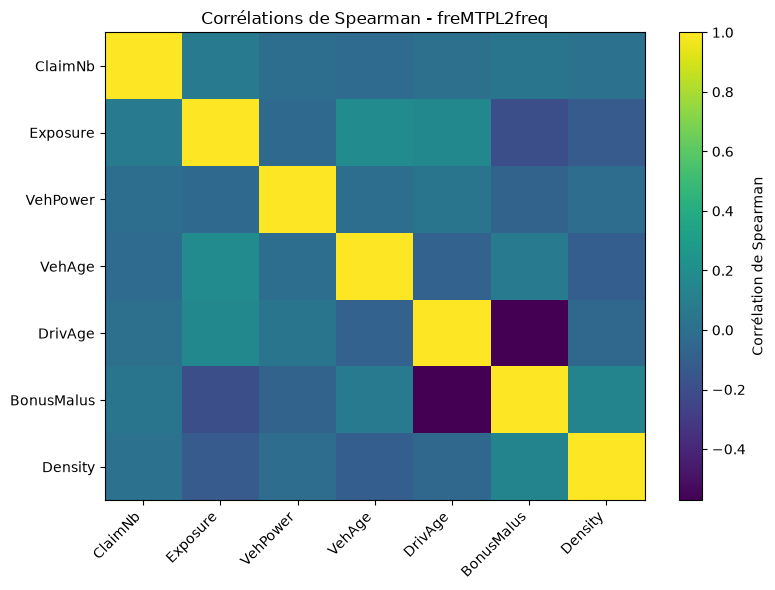

In [57]:
plt.figure(figsize=(8,6))

plt.imshow(
    corr_freq,
    aspect="auto"
)

plt.colorbar(
    label="Corrélation de Spearman"
)

plt.xticks(
    range(len(corr_freq.columns)),
    corr_freq.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_freq.index)),
    corr_freq.index
)

plt.title(
    "Corrélations de Spearman - freMTPL2freq"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "freq_spearman_correlation.png",
    dpi=150
)

plt.show()

# Bilan EDA - freMTPL2freq

Plusieurs associations descriptives apparaissent : 

- la cible est fortement déséquilibrée
- l'exposition varie fortement entre les contrats 
- l'age du conducteur présente une relation non linéaire avec la fréquence 
- BonusMalus présente une relation non linéaire avec la fréquence 
- la densité semble associée à une augmentation progressive de la fréquence 
- les zones 'Area' présentent des niveaux de fréquence différents 
- certaines catégories de région et de marque présentent également des différences 
- plusierus varaibles numériques sont fortement asymétriques 

ces observations ne constituent pas de preuves de causalité 

Elles guideront les étapes de nettoyage , feature enginnering et sélection des modèles 

# Partie B — Vehicle Claim Fraud

## Définition du problème

L'objectif futur est de prédire `FraudFound_P`.

Cependant, avant la modélisation, il est nécessaire de définir
le moment auquel la prédiction doit être produite.

Dans ce projet, nous considérons provisoirement que la prédiction
doit être disponible lors du traitement initial de la déclaration.

Toute variable connue uniquement après une enquête ou une décision
ultérieure devra être étudiée comme risque potentiel de data leakage.

In [58]:
fraud_counts = (
    fraud_eda["FraudFound_P"]
    .value_counts()
    .sort_index()
)


fraud_counts

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [59]:
fraud_rate = (
    fraud_eda["FraudFound_P"]
    .mean()
)

print(
    f"Taux de fraude : {fraud_rate:0.4%}"
)

Taux de fraude : 5.9857%


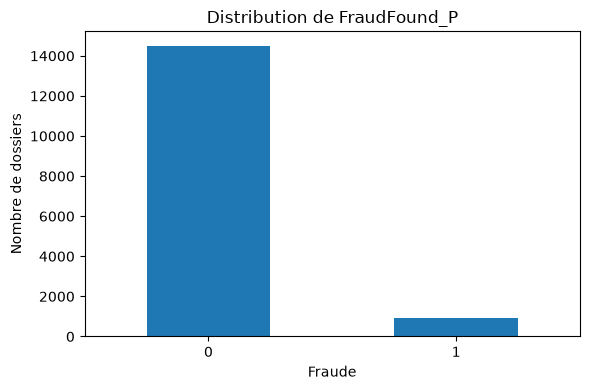

In [61]:
plt.figure(figsize=(6,4))

fraud_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution de FraudFound_P"
)

plt.xlabel(
    "Fraude"
)

plt.ylabel(
    "Nombre de dossiers"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "freq_target_distribution.png"
)

plt.show()

In [67]:
def fraud_rate_table(
        df,
        group_col
):

    table = (
        df
        .groupby(
            group_col,
            dropna=False
        )
        .agg(
            n=("FraudFound_P","size"),
            frauds=("FraudFound_P","sum"),
            fraud_rate=("FraudFound_P","mean")
        )
    )

    return table.sort_values(
        "fraud_rate",
        ascending=False
    )

In [68]:
fault_table = fraud_rate_table(
    fraud_eda,
    "Fault"
)

fault_table

,n,frauds,fraud_rate
Fault,,,
Policy Holder,11230,886,0.078896
Third Party,4190,37,0.008831


In [69]:
base_policy_table = fraud_rate_table(
    fraud_eda,
    "BasePolicy"
)

base_policy_table

,n,frauds,fraud_rate
BasePolicy,,,
All Perils,4449,452,0.101596
Collision,5962,435,0.072962
Liability,5009,36,0.007187


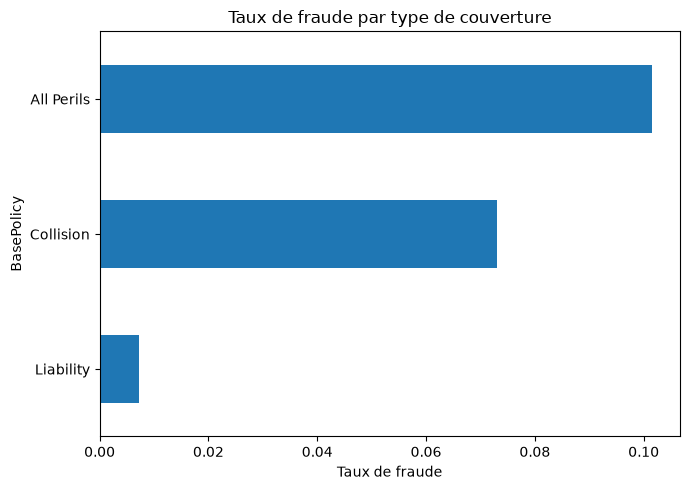

In [70]:
plt.figure(figsize=(7,5))

base_policy_table[
    "fraud_rate"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Taux de fraude par type de couverture"
)

plt.xlabel(
    "Taux de fraude"
)

plt.ylabel(
    "BasePolicy"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fraud_base_policy_rate.png",
    dpi=150
)

plt.show()

In [72]:
vehicule_category_table = fraud_rate_table(
    fraud_eda,
    "VehicleCategory"
)

vehicule_category_table

,n,frauds,fraud_rate
VehicleCategory,,,
Utility,391,44,0.112532
Sedan,9671,795,0.082205
Sport,5358,84,0.015677


In [73]:
fraud_rate_table(
    fraud_eda,
    "AccidentArea"
)

,n,frauds,fraud_rate
AccidentArea,,,
Rural,1598,133,0.083229
Urban,13822,790,0.057155


In [74]:
fraud_rate_table(
    fraud_eda,
    "Sex"
)

,n,frauds,fraud_rate
Sex,,,
Male,13000,818,0.062923
Female,2420,105,0.043388


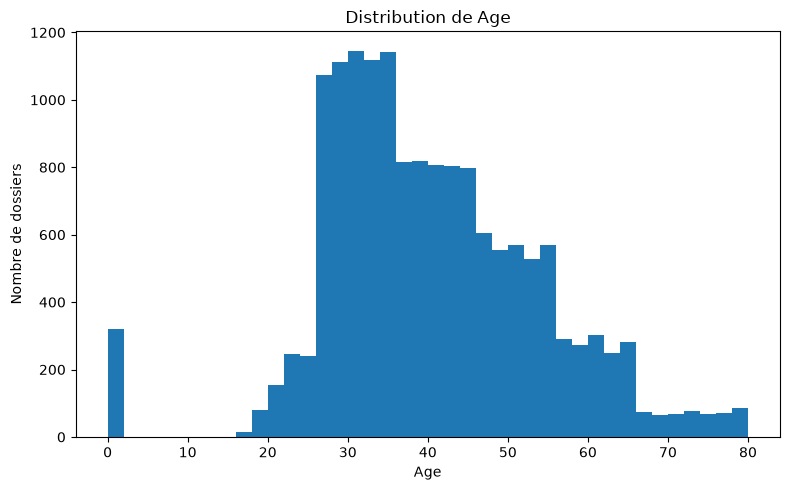

In [75]:
plt.figure(figsize=(8,5))

plt.hist(
    fraud_eda["Age"],
    bins=40
)

plt.title(
    "Distribution de Age"
)

plt.xlabel("Age")

plt.ylabel("Nombre de dossiers")

plt.tight_layout()

plt.show()

In [76]:
fraud_age_valid = fraud_eda.loc[
    fraud_eda["Age"] > 0
].copy()

In [77]:
fraud_age_valid["AgeBin"] = pd.cut(
    fraud_age_valid["Age"],
    bins=[
        15,
        20,
        25,
        30,
        35,
        40,
        50,
        60,
        70,
        80
    ]
)

In [78]:
age_fraud_table = fraud_rate_table(
    fraud_age_valid,
    "AgeBin"
)

age_fraud_table.sort_index()

,n,frauds,fraud_rate
AgeBin,,,
"(15, 20]",123,18,0.146341
"(20, 25]",613,33,0.053834
"(25, 30]",2783,170,0.061085
"(30, 35]",2810,190,0.067616
"(35, 40]",2018,127,0.062934
"(40, 50]",3475,186,0.053525
"(50, 60]",2096,102,0.048664
"(60, 70]",838,50,0.059666
"(70, 80]",344,16,0.046512


In [79]:
address_change_table = fraud_rate_table(
    fraud_eda,
    "AddressChange_Claim"
)

address_change_table

,n,frauds,fraud_rate
AddressChange_Claim,,,
under 6 months,4,3,0.750000
2 to 3 years,291,51,0.175258
1 year,170,11,0.064706
no change,14324,825,0.057596
4 to 8 years,631,33,0.052298


In [80]:
def reliable_fraud_groups(
    df,
    group_col,
    min_count=100
):

    table = fraud_rate_table(
        df,
        group_col
    )

    return table.loc[
        table["n"] >= min_count
    ]

In [81]:
reliable_fraud_groups(
    fraud_eda,
    "Make",
    min_count=100
)

,n,frauds,fraud_rate
Make,,,
Accura,472,59,0.125000
Saab,108,11,0.101852
Ford,450,33,0.073333
Honda,2801,179,0.063906
Toyota,3121,186,0.059596
Chevrolet,1681,94,0.055919
Pontiac,3837,213,0.055512
Mazda,2354,123,0.052251
VW,283,8,0.028269


In [82]:
policy_type_table = reliable_fraud_groups(
    fraud_eda,
    "PolicyType",
    min_count=100
)

policy_type_table

,n,frauds,fraud_rate
PolicyType,,,
Sport - Collision,348,48,0.137931
Utility - All Perils,340,41,0.120588
Sedan - All Perils,4087,411,0.100563
Sedan - Collision,5584,384,0.068768
Sedan - Liability,4987,36,0.007219


In [83]:
pd.crosstab(
    fraud_eda["PolicyType"],
    fraud_eda["BasePolicy"]
)

BasePolicy,All Perils,Collision,Liability
PolicyType,,,
Sedan - All Perils,4087,0,0
Sedan - Collision,0,5584,0
Sedan - Liability,0,0,4987
Sport - All Perils,22,0,0
Sport - Collision,0,348,0
Sport - Liability,0,0,1
Utility - All Perils,340,0,0
Utility - Collision,0,30,0
Utility - Liability,0,0,21


In [84]:
pd.crosstab(
    fraud_eda["PolicyType"],
    fraud_eda["VehicleCategory"]
)

VehicleCategory,Sedan,Sport,Utility
PolicyType,,,
Sedan - All Perils,4087,0,0
Sedan - Collision,5584,0,0
Sedan - Liability,0,4987,0
Sport - All Perils,0,22,0
Sport - Collision,0,348,0
Sport - Liability,0,1,0
Utility - All Perils,0,0,340
Utility - Collision,0,0,30
Utility - Liability,0,0,21


In [85]:
fraud_rate_table(
    fraud_eda,
    "PastNumberOfClaims"
)

,n,frauds,fraud_rate
PastNumberOfClaims,,,
none,4352,339,0.077895
1,3573,222,0.062133
2 to 4,5485,294,0.053601
more than 4,2010,68,0.033831


In [86]:
year_table = fraud_rate_table(
    fraud_eda,
    "Year"
).sort_index()

year_table

,n,frauds,fraud_rate
Year,,,
1994,6142,409,0.066591
1995,5195,301,0.057940
1996,4083,213,0.052168


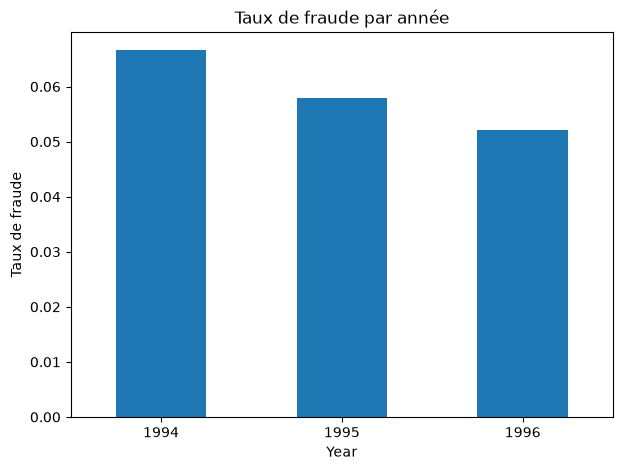

In [87]:
plt.figure(figsize=(7,5))

year_table[
    "fraud_rate"
].plot(
    kind="bar"
)

plt.title(
    "Taux de fraude par année"
)

plt.xlabel("Year")

plt.ylabel(
    "Taux de fraude"
)

plt.xticks(rotation=0)

plt.savefig(
    FIGURES_DIR / "fraude_rate_by_year.png"
)

plt.show()

In [88]:
month_table = fraud_rate_table(
    fraud_eda,
    "Month"
)

month_table

,n,frauds,fraud_rate
Month,,,
Mar,1360,102,0.075000
Aug,1127,84,0.074534
May,1367,94,0.068764
Feb,1266,82,0.064771
Apr,1280,80,0.062500
Jan,1411,87,0.061658
Sep,1240,76,0.061290
Jun,1321,80,0.060560
Oct,1305,70,0.053640


## Analyse du risque de data leakage 

Avant la modèlisation ,chaque variable doit etre classée selon le moment ou elle devient disponible 

Une variable ne peut pas etre utilisée pour prédire la fraude si elle n'est connue qu'aprés la décision de fraude 

Variables à examiner attentivement :

- Fault 
- PoliceReportFiled
- WitnessPresent 
- NumberOfSuppliments
- Days_Policy_Claim
- AdressChange_Claim

Ces variables ne seront pas automatiquement supprimées 

La documentation métier devra permettre de déterminer si elles sont disponibles au moment de la prédiction 

In [98]:
from scipy.stats import chi2_contingency

def chi_square_test(
    df,
    feature,
    target
):

    contingency = pd.crosstab(
        df[feature],
        df[target]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency
        )
    )


    return {
        "feature": feature,
        "chi2" : chi2,
        "p_value" : p_value,
        "dof" : dof
    }

    

In [99]:
chi_square_test(
    fraud_eda,
    "BasePolicy",
    "FraudFound_P"
)

{'feature': 'BasePolicy',
 'chi2': np.float64(402.8519212497997),
 'p_value': np.float64(3.325192471427785e-88),
 'dof': 2}

In [105]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.to_numpy().sum()

    phi2 = chi2 / n            # <- was: phi2 = chi2_contingency

    r, k = confusion.shape
    denominator = min(k - 1, r - 1)

    if denominator == 0:
        return 0.0

    return np.sqrt(phi2 / denominator)

In [106]:
categorical_features = [
    "Fault",
    "AccidentArea",
    "BasePolicy",
    "VehicleCategory",
    "PolicyType",
    "Sex",
    "AgentType"
]

associations = []

for col in categorical_features:

    associations.append({
        "feature": col,
        "cramers_v": cramers_v(
            fraud_eda[col],
            fraud_eda["FraudFound_P"]
        )
    })

pd.DataFrame(
    associations
).sort_values(
    "cramers_v",
    ascending=False
)

,feature,cramers_v
4,PolicyType,0.168422
2,BasePolicy,0.161633
3,VehicleCategory,0.137360
0,Fault,0.131389
1,AccidentArea,0.033499
5,Sex,0.029953
6,AgentType,0.022978


In [107]:
interaction = (
    fraud_eda
    .groupby(
        [
            "BasePolicy",
            "Fault"
        ]
    )
    .agg(
        n=("FraudFound_P","size"),
        fraud_rate=("FraudFound_P","mean")
    )
)

interaction.loc[
    interaction["n"] >= 100
]

n  fraud_rate
BasePolicy Fault                          
All Perils Policy Holder  2797    0.155881
           Third Party    1652    0.009685
Collision  Policy Holder  4151    0.099976
           Third Party    1811    0.011044
Liability  Policy Holder  4282    0.008174
           Third Party     727    0.001376

In [108]:
interaction_vehicle = (
    fraud_eda
    .groupby(
        [
            "VehicleCategory",
            "AccidentArea"
        ]
    )
    .agg(
        n=("FraudFound_P","size"),
        fraude_rate=("FraudFound_P","mean")
    )
)

interaction_vehicle.loc[
    interaction_vehicle["n"] >= 100
].sort_values(
    "fraude_rate",
    ascending=False
)

n  fraude_rate
VehicleCategory AccidentArea                   
Utility         Urban          335     0.110448
Sedan           Rural         1129     0.103632
                Urban         8542     0.079373
Sport           Rural          413     0.021792
                Urban         4945     0.015167

In [109]:
eda_hypotheses = pd.DataFrame([
    {
        "dataset": "freMTPL2freq",
        "feature": "DrivAge",
        "observation": "Relation non linéaire avec la fréquence",
        "next_step": "Tester forme brute et modèles non linéaires"
    },
    {
        "dataset": "freMTPL2freq",
        "feature": "BonusMalus",
        "observation": "Association forte avec ClaimNb",
        "next_step": "Conserver et étudier les valeurs extrêmes"
    },
    {
        "dataset": "freMTPL2freq",
        "feature": "Density",
        "observation": "Distribution très asymétrique",
        "next_step": "Tester log1p durant feature engineering"
    },
    {
        "dataset": "fraud",
        "feature": "BasePolicy",
        "observation": "Taux de fraude très différent entre catégories",
        "next_step": "Conserver et encoder"
    },
    {
        "dataset": "fraud",
        "feature": "Fault",
        "observation": "Association forte avec la cible",
        "next_step": "Vérifier risque de leakage"
    },
    {
        "dataset": "fraud",
        "feature": "Year",
        "observation": "Taux de fraude évolue dans le temps",
        "next_step": "Étudier split temporel"
    },
    {
        "dataset": "fraud",
        "feature": "PolicyNumber",
        "observation": "Identifiant unique",
        "next_step": "Exclure probablement du ML"
    }
])

eda_hypotheses

,dataset,feature,observation,next_step
0,freMTPL2freq,DrivAge,Relation non linéaire avec la fréquence,Tester forme brute et modèles non linéaires
1,freMTPL2freq,BonusMalus,Association forte avec ClaimNb,Conserver et étudier les valeurs extrêmes
2,freMTPL2freq,Density,Distribution très asymétrique,Tester log1p durant feature engineering
3,fraud,BasePolicy,Taux de fraude très différent entre catégories,Conserver et encoder
4,fraud,Fault,Association forte avec la cible,Vérifier risque de leakage
5,fraud,Year,Taux de fraude évolue dans le temps,Étudier split temporel
6,fraud,PolicyNumber,Identifiant unique,Exclure probablement du ML


In [110]:
EDA_REPORT_DIR = (
    RAW_DIR.parent.parent
    / "reports"
    / "eda"
)

EDA_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

eda_hypotheses.to_csv(
    EDA_REPORT_DIR / "eda_hypotheses.csv",
    index=False
)

# Conclusion EDA — freMTPL2freq

L'analyse exploratoire confirme que le problème d'assurance
présente une structure fortement déséquilibrée.

Environ 5 % des polices possèdent au moins un sinistre.

La prise en compte de `Exposure` est indispensable :
la fréquence agrégée est d'environ 0,10 sinistre par unité
d'exposition.

Plusieurs associations descriptives ont été identifiées :

- `DrivAge` présente une relation non linéaire avec la fréquence ;
- les jeunes conducteurs présentent une fréquence descriptive élevée ;
- `BonusMalus` possède une association forte avec la fréquence ;
- `Density` présente une relation croissante avec la fréquence ;
- `Area` sépare des groupes avec des fréquences différentes ;
- `VehAge`, `Region`, `VehGas` et `VehBrand` présentent également
  des variations.

Certaines variables possèdent des distributions fortement asymétriques
ou des valeurs extrêmes.

Ces relations sont descriptives et ne doivent pas être interprétées
comme causales.

Les prochaines étapes devront déterminer quelles transformations
sont justifiées et lesquelles doivent rester brutes.

# Conclusion EDA — Vehicle Claim Fraud

La cible `FraudFound_P` est fortement déséquilibrée :
environ 6 % des observations sont frauduleuses.

Plusieurs variables présentent des associations descriptives
avec la cible, notamment :

- `Fault` ;
- `BasePolicy` ;
- `PolicyType` ;
- `VehicleCategory` ;
- `AccidentArea` ;
- certaines catégories liées à l'historique de contrat.

Les taux observés doivent toujours être interprétés avec leur
nombre d'observations.

Certaines catégories affichent des taux très élevés mais sont
représentées par très peu de lignes, ce qui rend leur estimation instable.

Une évolution du taux de fraude apparaît également selon `Year`,
ce qui suggère un potentiel effet temporel.

Enfin, certaines variables pourraient contenir de l'information
postérieure au moment où le modèle doit produire sa prédiction.
Un audit du risque de data leakage sera donc nécessaire avant
la modélisation.

# Bilan général de l'EDA

Les deux datasets présentent des problèmes de Machine Learning
supervisé très différents.

## freMTPL2freq

Deux tâches futures sont envisagées :

1. classification de l'occurrence d'un sinistre ;
2. modélisation de la fréquence des sinistres avec prise en compte
   de l'exposition.

## Vehicle Claim Fraud

Le problème est une classification binaire fortement déséquilibrée.

Les prochaines étapes devront notamment traiter :

- les valeurs atypiques ;
- les catégories spéciales ;
- les variables identifiantes ;
- la représentation des catégories ;
- les distributions asymétriques ;
- le déséquilibre des classes ;
- le risque de data leakage ;
- l'éventuelle structure temporelle.

Aucun modèle n'est encore entraîné.

La prochaine étape est le nettoyage contrôlé des données
dans `03_cleaning.ipynb`.